# Model Evaluation
This notebook evaluates the trained MobileNetV2 model for the Face Mask Compliance Detection System.


In [6]:
import os
import json
import logging
import subprocess

# Suppress TensorFlow and ABSL warnings completely
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from IPython.display import Image, display

# Suppress Keras UserWarnings (like the compiled metrics warning)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


In [7]:
# 1. Download Dataset from Kaggle if missing
VAL_DIR = "Data/processed/val"
ZIP_PATH = "Data/face-mask-compliance-detection-system-dataset-v1.zip"

if not os.path.exists(VAL_DIR):
    print("Validation dataset not found locally. Downloading from Kaggle...")
    try:
        # Assuming the kaggle CLI is installed and configured since you uploaded the dataset
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", "kamaleshsp/face-mask-compliance-detection-system-dataset-v1", "-p", "Data", "--unzip"], 
            check=True
        )
        print("Dataset downloaded and extracted successfully!")
    except Exception as e:
        print(f"Error downloading dataset. Please ensure the Kaggle CLI is installed ('pip install kaggle') and your API token is configured.\nError Details: {e}")
        
    # Fallback: if kaggle skipped the download/extraction because the zip already exists
    if os.path.exists(ZIP_PATH) and not os.path.exists(VAL_DIR):
        print("Zip file found but not unzipped. Extracting now...")
        import zipfile
        try:
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall("Data")
            print("Extraction complete!")
        except Exception as e:
            print(f"Failed to extract zip file: {e}")
else:
    print(f"Dataset already exists at {VAL_DIR}. Skipping download.")


Dataset already exists at Data/processed/val. Skipping download.


In [8]:
# 2. Load the trained model and labels
MODEL_PATH = "Model/mask_detector_mobilenetv2.h5"
LABELS_PATH = "Model/class_labels.json"

print(f"Loading model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

with open(LABELS_PATH, "r") as f:
    class_indices = json.load(f)
    
# Convert keys to integers
class_labels = {int(k): v for k, v in class_indices.items()}
class_names = [class_labels[i] for i in range(len(class_labels))]

print("Model Loaded Successfully!")
print("Classes:", class_names)


Loading model from Model/mask_detector_mobilenetv2.h5...
Model Loaded Successfully!
Classes: ['proper_mask', 'no_mask', 'incorrect_mask']


In [9]:
# 3. Load the Validation Dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"Loading validation data from {VAL_DIR}...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names, # Important: Ensures the validation classes map to exactly what the model was trained on!
    shuffle=False # Important: Do not shuffle for evaluation so we can match labels!
)

# Important: Rescale pixel values from [0, 255] to [0, 1] to match training preprocessing
val_dataset = val_dataset.map(lambda x, y: (x / 255.0, y))



Loading validation data from Data/processed/val...
Found 4813 files belonging to 3 classes.


In [10]:
# 4. Model Evaluation (Test Loss & Accuracy)
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"\nTesting/Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Testing/Validation Loss: {val_loss:.4f}")


Evaluating model...
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 373ms/step - accuracy: 0.9339 - loss: 0.1685

Testing/Validation Accuracy: 93.39%
Testing/Validation Loss: 0.1685


In [11]:
# 5. Generate Predictions
print("Generating predictions...")
predictions = model.predict(val_dataset, verbose=0)
y_pred = np.argmax(predictions, axis=1)

# Get true labels directly from the dataset
y_true_categorical = np.concatenate([y for x, y in val_dataset], axis=0)
y_true = np.argmax(y_true_categorical, axis=1)


Generating predictions...


In [12]:
# 6. Classification Report & Accuracy Score
acc_score = accuracy_score(y_true, y_pred)
print(f"\nAccuracy Score: {acc_score * 100:.2f}%")

print("\n--- Classification Report ---")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)



Accuracy Score: 93.39%

--- Classification Report ---
                precision    recall  f1-score   support

   proper_mask       0.94      0.91      0.92      1605
       no_mask       0.89      0.96      0.92      1604
incorrect_mask       0.98      0.93      0.96      1604

      accuracy                           0.93      4813
     macro avg       0.94      0.93      0.93      4813
  weighted avg       0.94      0.93      0.93      4813



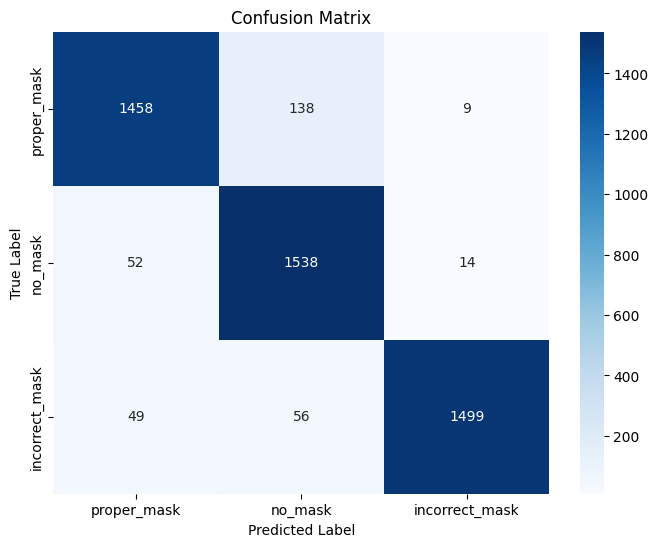

In [13]:
# 7. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


--- Training History ---


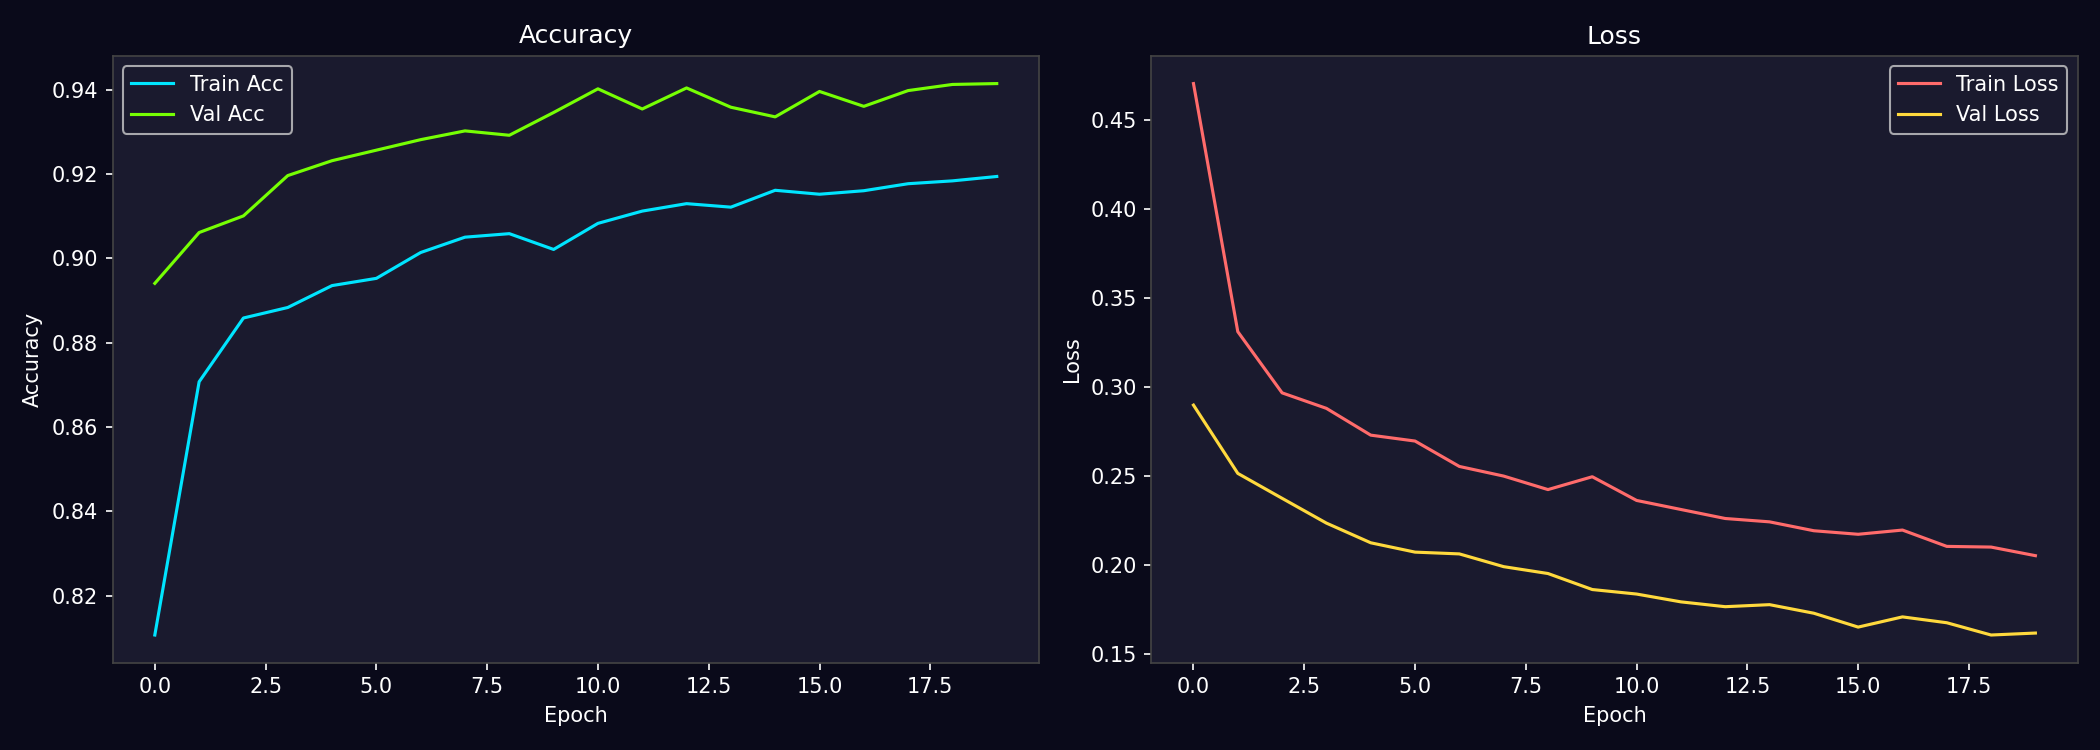

In [14]:
# 8. Training History
history_path = "Model/training_history.png"
if os.path.exists(history_path):
    print("--- Training History ---")
    display(Image(filename=history_path))
else:
    print("Training history image not found.")
